In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = "0"
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

import pandas as pd
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.layers import LSTM, RepeatVector,TimeDistributed, Dense, Input

               Sales
Month               
2001-01-01  1359.795
2002-01-01  1278.564
2003-01-01  1508.327
2004-01-01  1419.710
2005-01-01  1440.510


<Axes: xlabel='Month'>

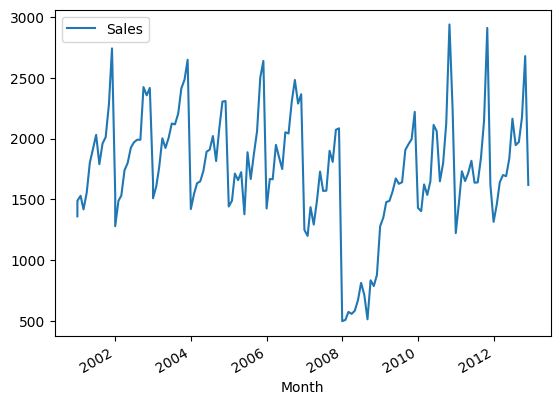

In [7]:

df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-writing-paper-sales.csv")
df["Month"] = df["Month"].str.replace("13", "01")
df["Month"] = pd.to_datetime(df["Month"], format="%m-%y")
df = df.set_index("Month")
print(df.head())
df.plot()

In [17]:
max_value = max(df['Sales'])
min_value = min(df['Sales'])

def normalize_data(data):
    return (data - min_value) / (max_value - min_value)

def denormalize_data(data):
    return data * (max_value - min_value) + min_value

normalized_df = normalize_data(df['Sales'])

n_features = 1
n_future = 12
n_past = 24

x = []
for i in range(len(normalized_df) - n_past - 1):
    window = normalized_df.iloc[i:i+n_past].to_numpy().reshape(-1, 1)
    x.append(window)
x = np.array(x)

y = []
for i in range(n_past, len(normalized_df)-n_future+1):
    window = normalized_df.iloc[i:i+n_future].to_numpy().reshape(-1, 1)
    y.append(window)
y = np.array(y)

train_size = 0.8
validation_size = 0.1
test_size = 0.1

indices = np.arange(min(len(x),len(y)))
np.random.shuffle(indices)
train_index = int(train_size * len(indices))
val_index = int((train_size + validation_size) * len(indices))

train_indices = indices[:train_index]
val_indices = indices[train_index:val_index]
test_indices = indices[val_index:]

x_train, y_train = x[train_indices], y[train_indices]
x_val, y_val = x[val_indices], y[val_indices]
x_test, y_test = x[test_indices], y[test_indices]

print("Number of samples in training set:", len(x_train))
print("Number of samples in validation set:", len(x_val))
print("Number of samples in test set:", len(x_test))

print(x_train.shape)
print(x_test.shape)
print(x_val.shape)

print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

Number of samples in training set: 89
Number of samples in validation set: 11
Number of samples in test set: 12
(89, 24, 1)
(12, 24, 1)
(11, 24, 1)
(89, 12, 1)
(12, 12, 1)
(11, 12, 1)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_48 (LSTM)                  │ (None, 24, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 24, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 24, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_51 (LSTM)                  │ (None, 24, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 24, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 24, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_54 (LSTM)                  │ (None, 24, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_55 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 12, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_56 (LSTM)                  │ (None, 12, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_57 (LSTM)                  │ (None, 12, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_58 (LSTM)                  │ (None, 12, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_59 (LSTM)                  │ (None, 12, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_60 (LSTM)                  │ (None, 12, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_61 (LSTM)                  │ (None, 12, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_62 (LSTM)                  │ (None, 12, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_63 (LSTM)                  │ (None, 12, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 12, 1)          │           101 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,246,901 (4.76 MB)

 Trainable params: 1,246,901 (4.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - loss: 0.3357 - val_loss: 0.3577
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - loss: 0.3187 - val_loss: 0.3350
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - loss: 0.2979 - val_loss: 0.3058
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - loss: 0.2715 - val_loss: 0.2683
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - loss: 0.2381 - val_loss: 0.2219
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - loss: 0.1977 - val_loss: 0.1705
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - loss: 0.1561 - val_loss: 0.1432
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - loss: 0.1454 - val_loss: 0.1508
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - loss: 0.1621 - val_loss: 0.1367
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - loss: 0.1458 - val_loss: 0.1236
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - loss: 0.1274 - val_loss: 0.1192
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step 

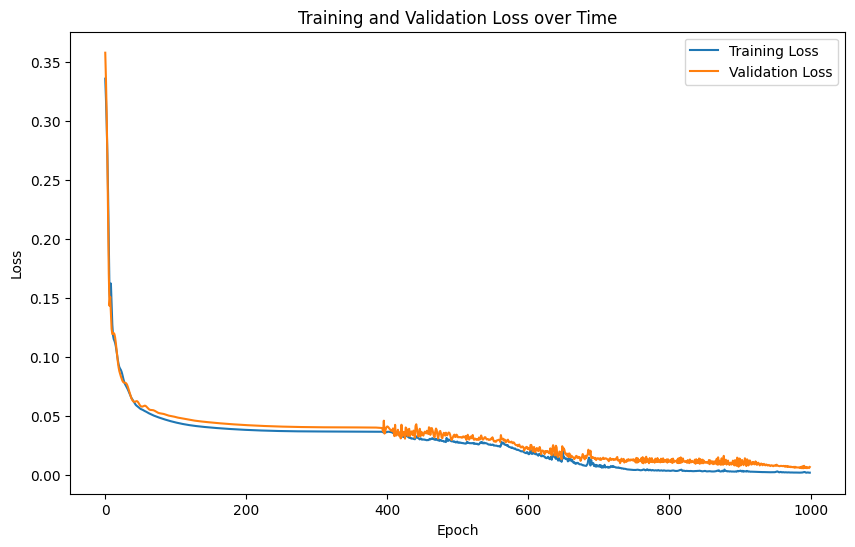

In [18]:
batch_size = x_train.shape[0]
epochs = 1000
hidden_layer = 100

model = Sequential()
model.add(LSTM(hidden_layer, input_shape=(n_past, n_features), return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer))
model.add(RepeatVector(n_future))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(LSTM(hidden_layer, return_sequences=True))
model.add(TimeDistributed(Dense(1)))
model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Time')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
MAPE: 6.094067157032449
RMSE: 107.6399128557684
AME: 90.34353495279947


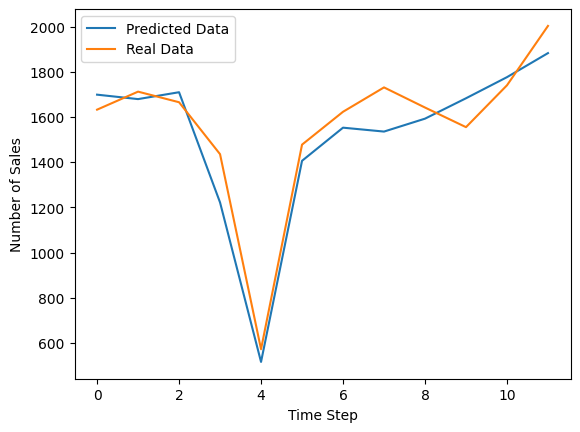

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
MAPE: 6.878204539566676
RMSE: 107.3599020527385
AME: 95.26341247558594


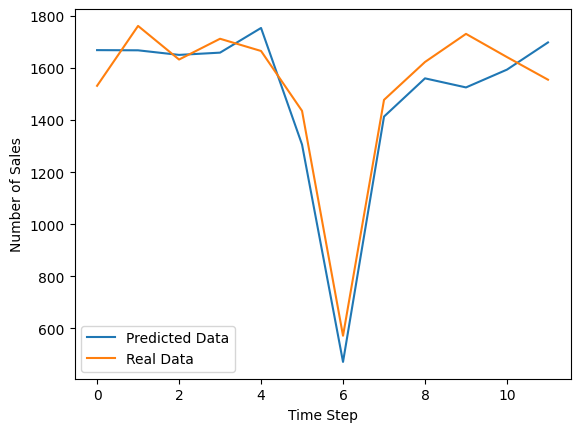

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
MAPE: 9.335664859542709
RMSE: 206.39263925598064
AME: 190.04587687174475


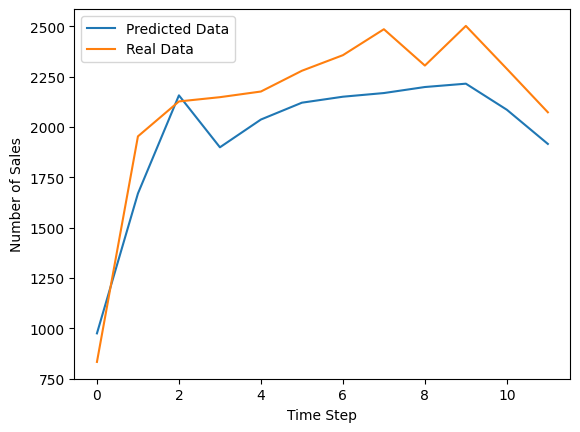

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
MAPE: 6.666719659902374
RMSE: 157.29584115868124
AME: 133.4568115234375


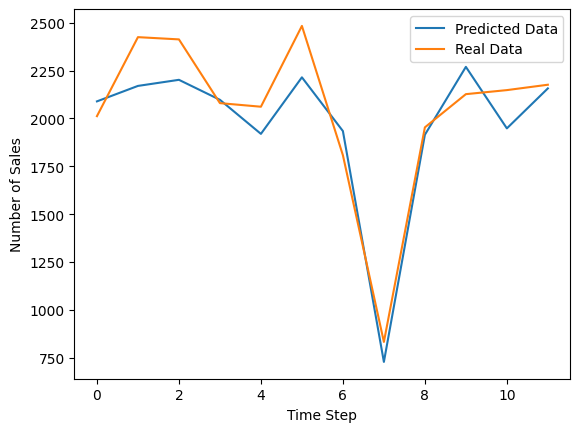

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
MAPE: 5.603523758414383
RMSE: 174.07149726300833
AME: 132.1042932128906


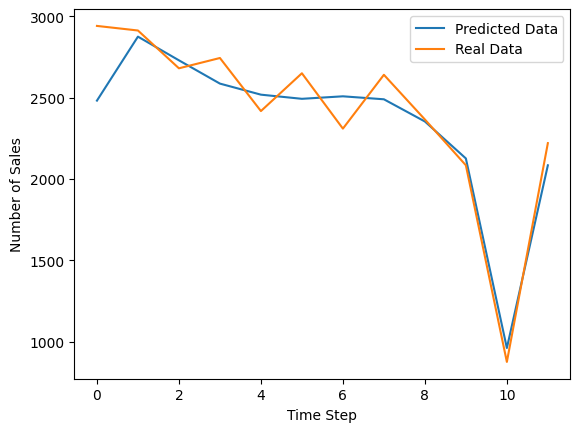

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
MAPE: 5.561575933279142
RMSE: 97.12155209297889
AME: 81.65929850260416


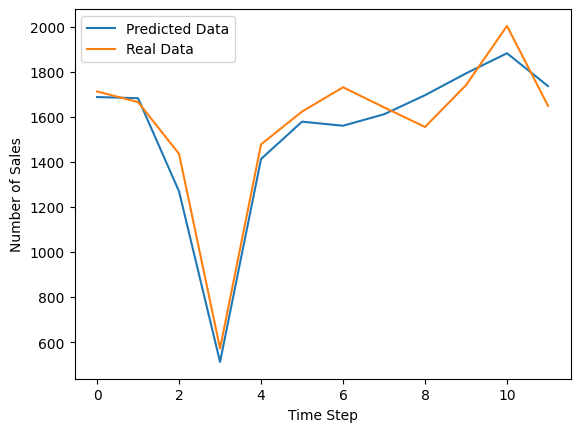

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
MAPE: 8.775336259447391
RMSE: 195.3948691993288
AME: 163.62725728352868


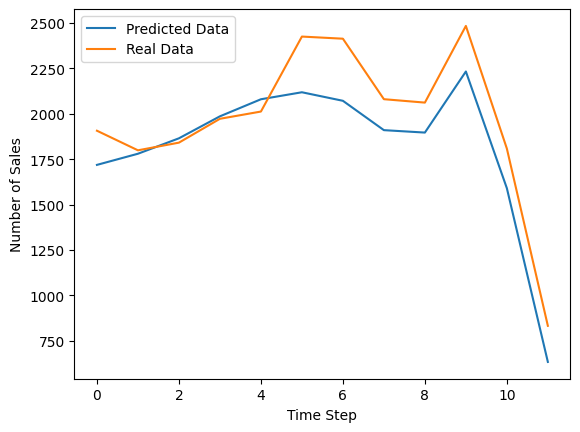

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
MAPE: 7.298345878076702
RMSE: 125.29259552924447
AME: 92.84094502766929


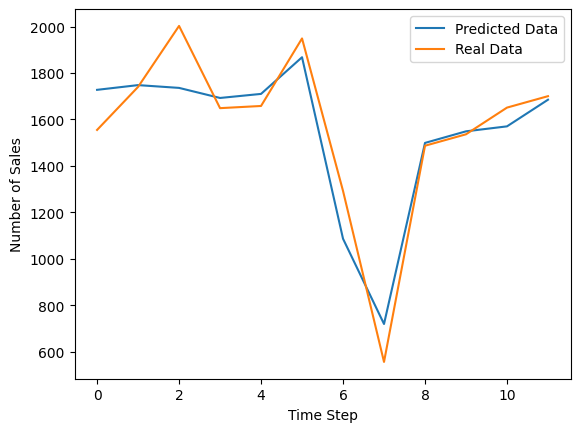

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
MAPE: 6.444492163859013
RMSE: 201.2317357503098
AME: 121.36023885091144


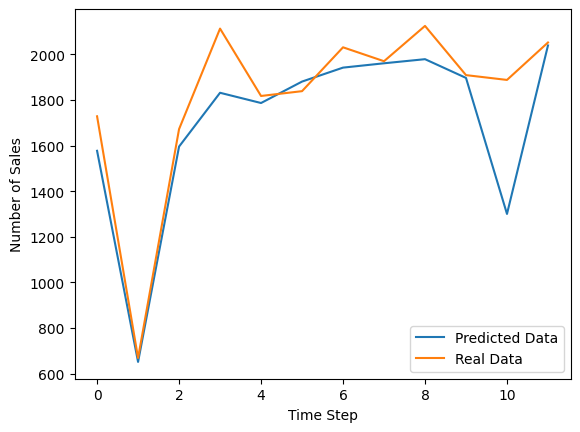

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
MAPE: 3.689112742079501
RMSE: 63.75113561700208
AME: 55.7986094156901


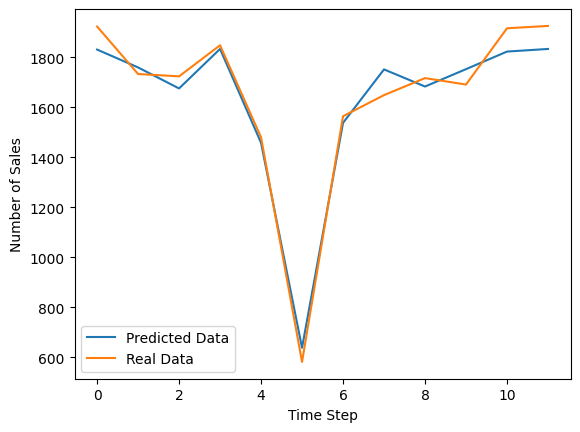

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
MAPE: 4.84705677452991
RMSE: 115.00236368104454
AME: 106.13959920247392


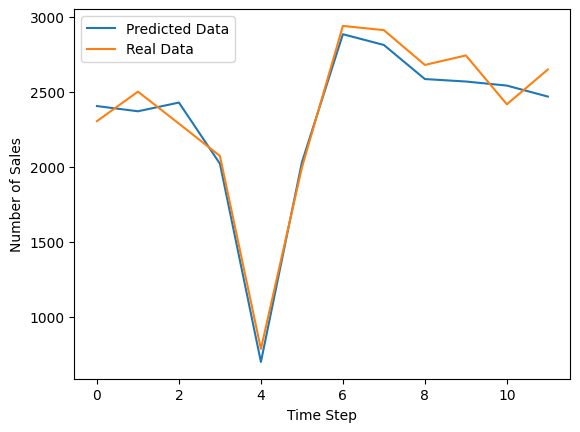

In [19]:
predictions = []
for i, x in enumerate(x_val):
    x = x.reshape(1,n_past,1)
    predicted = denormalize_data(model.predict(x)).flatten()
    predictions.append(predicted)
    real = denormalize_data(y_val[i].flatten())
    
    print(f"MAPE: {np.mean(np.abs((real - predicted) / real)) * 100}")
    print(f"RMSE: {np.sqrt(np.mean((real - predicted) ** 2))}")
    print(f"AME: {np.mean(np.abs(real - predicted))}")
    
    plt.plot(predicted, label='Predicted Data')
    plt.plot(real, label='Real Data')
    plt.xlabel('Time Step')
    plt.ylabel('Number of Sales')
    plt.legend()
    plt.show()

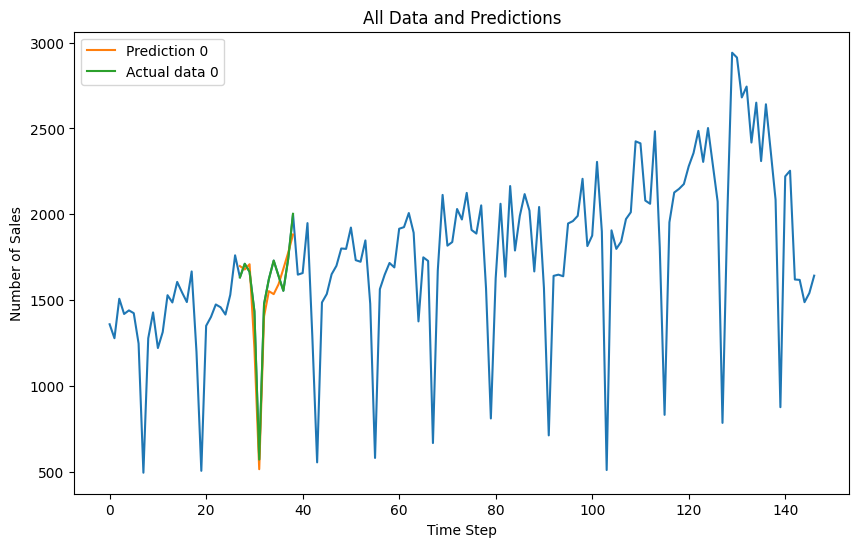

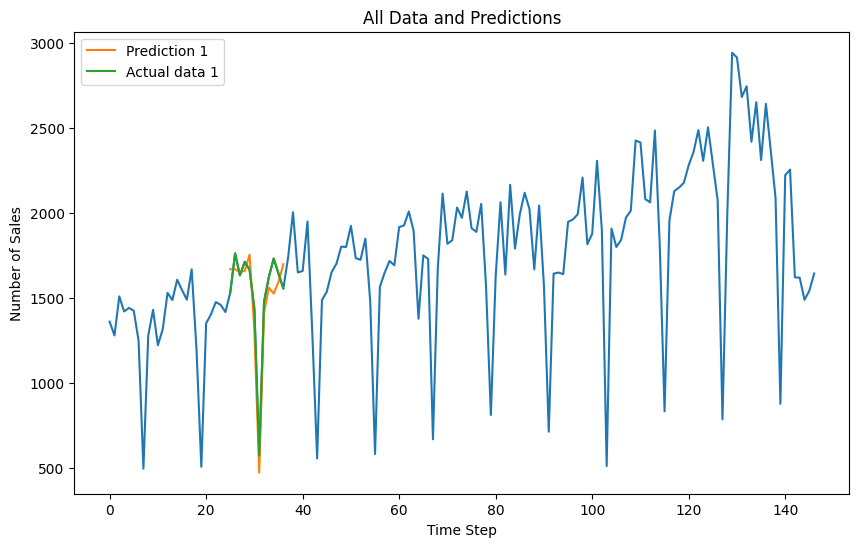

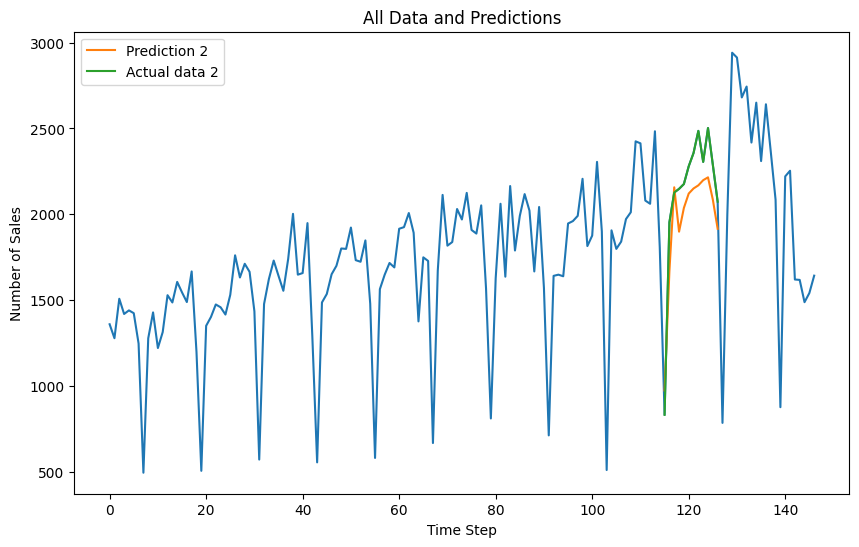

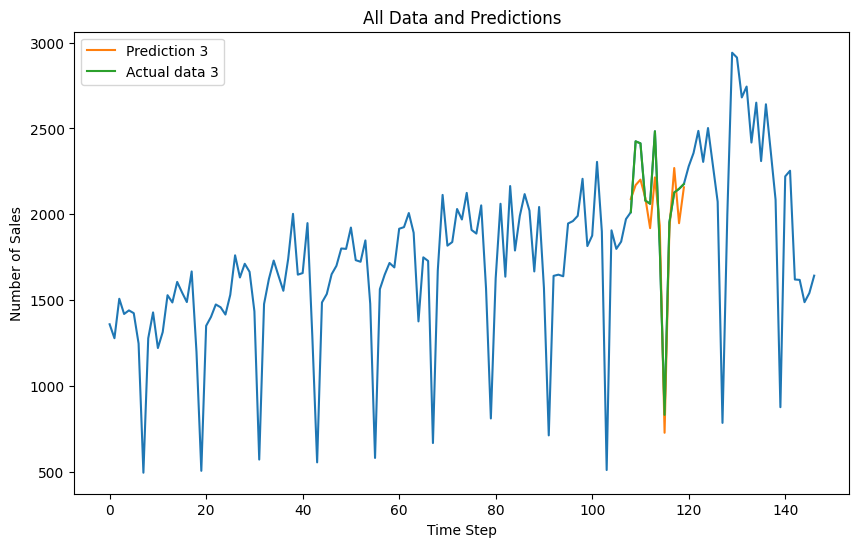

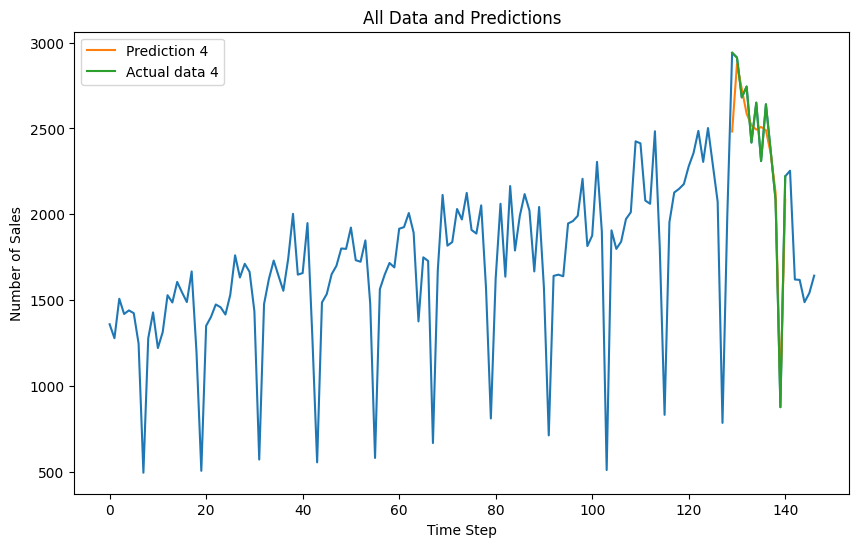

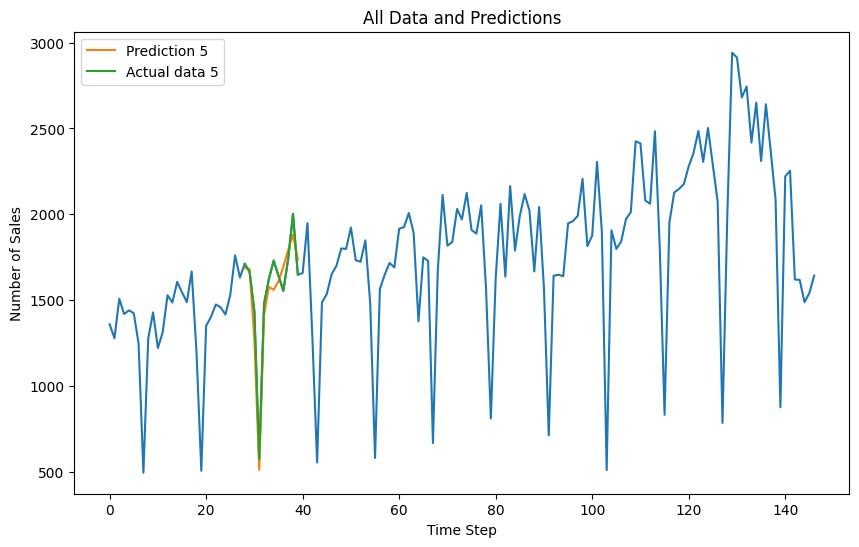

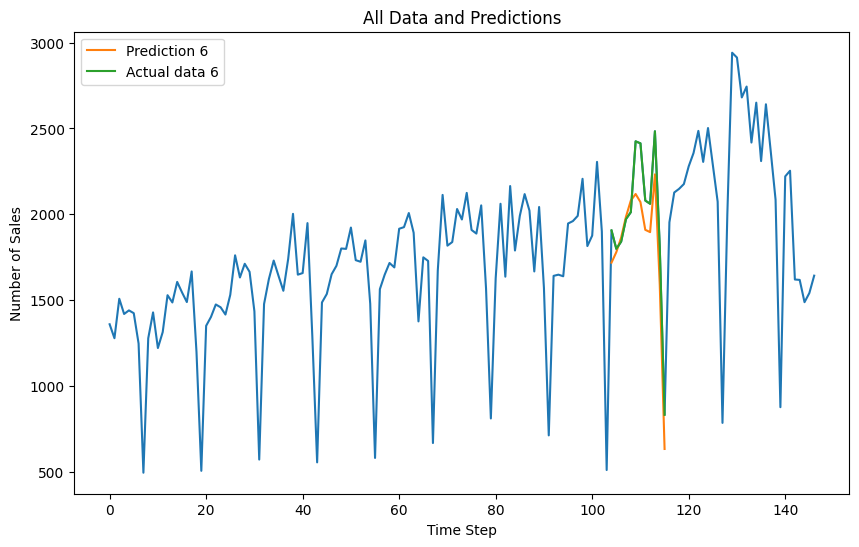

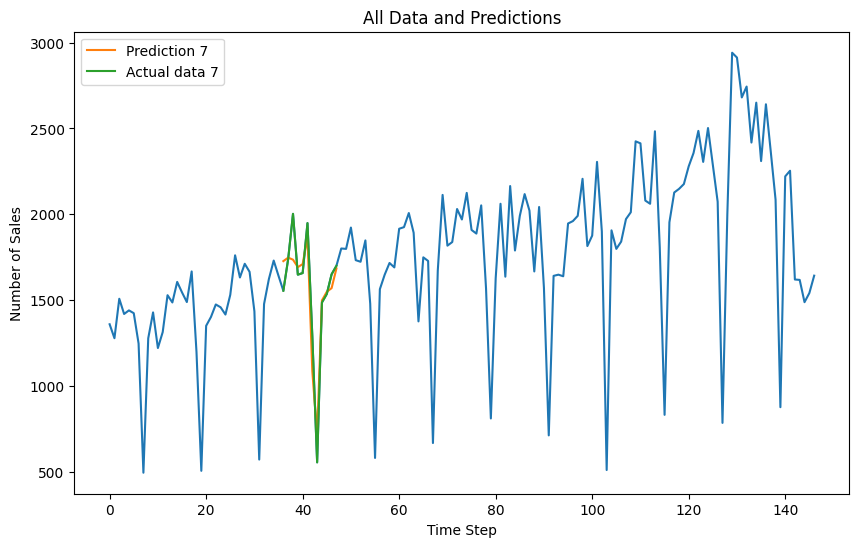

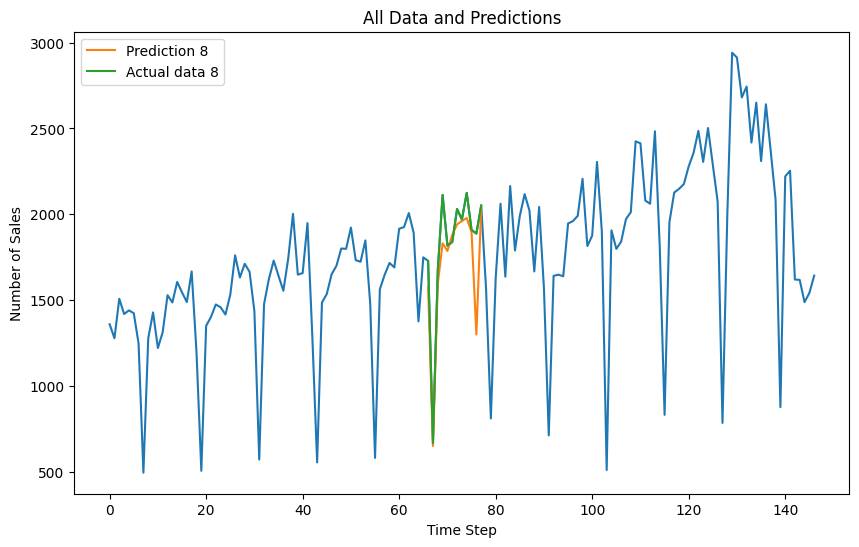

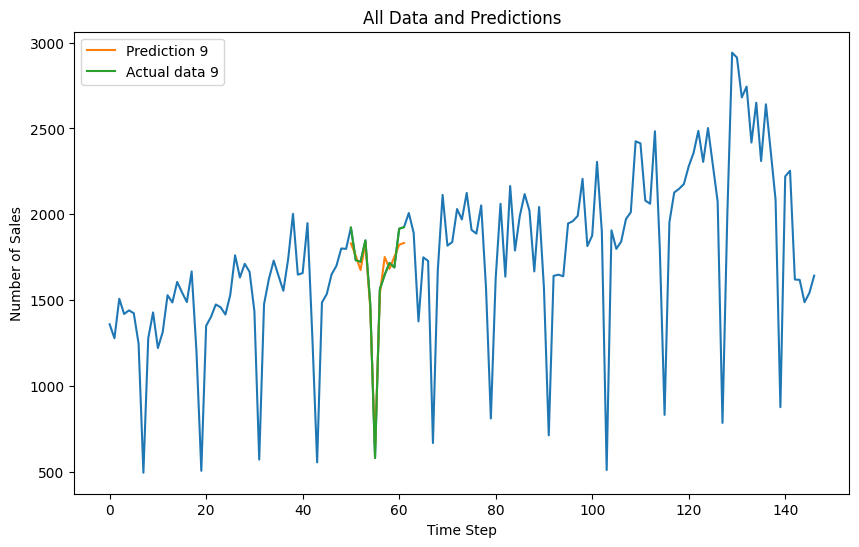

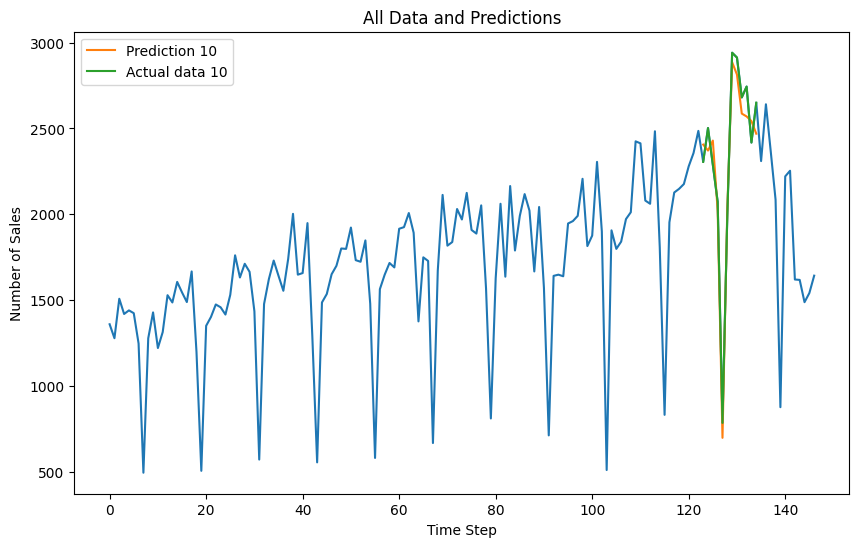

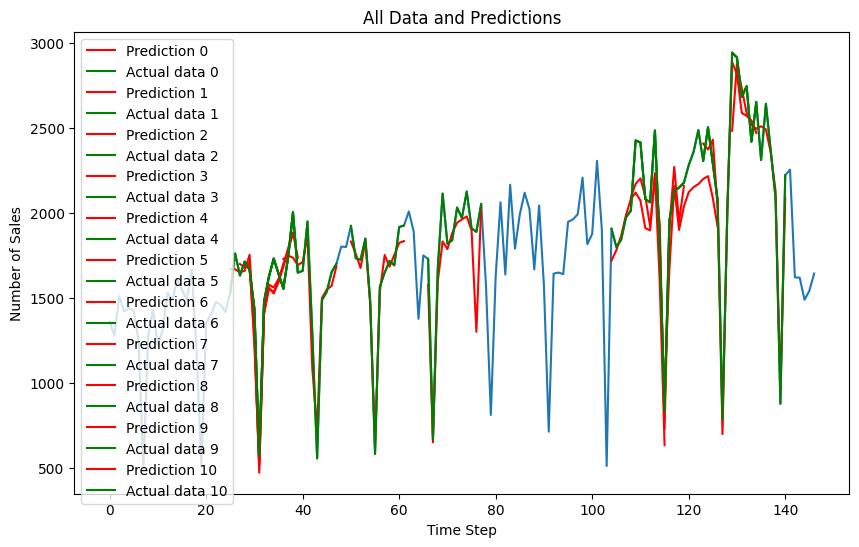

In [20]:
Sales_value = denormalize_data(normalize_data(df['Sales'].values))
predicted_values = []

for i, p in enumerate(predictions):
    index = val_indices[i] + n_past
    x_values = [j for j in range(index,index+n_future)]
    plt.figure(figsize=(10, 6))
    plt.plot(Sales_value)
    plt.plot(x_values,p, label=f"Prediction {i}")
    plt.plot(x_values,denormalize_data(y_val[i].flatten()), label=f"Actual data {i}")
    plt.xlabel('Time Step')
    plt.ylabel('Number of Sales')
    plt.title('All Data and Predictions')
    plt.legend()
    plt.show()

plt.figure(figsize=(10, 6))
plt.plot(Sales_value)

for i, p in enumerate(predictions):
    index = val_indices[i] + n_past
    x_values = [j for j in range(index,index+n_future)]
    plt.plot(x_values,p, label=f"Prediction {i}", color="red")
    plt.plot(x_values,denormalize_data(y_val[i].flatten()), label=f"Actual data {i}", color="green")

plt.xlabel('Time Step')
plt.ylabel('Number of Sales')
plt.title('All Data and Predictions')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


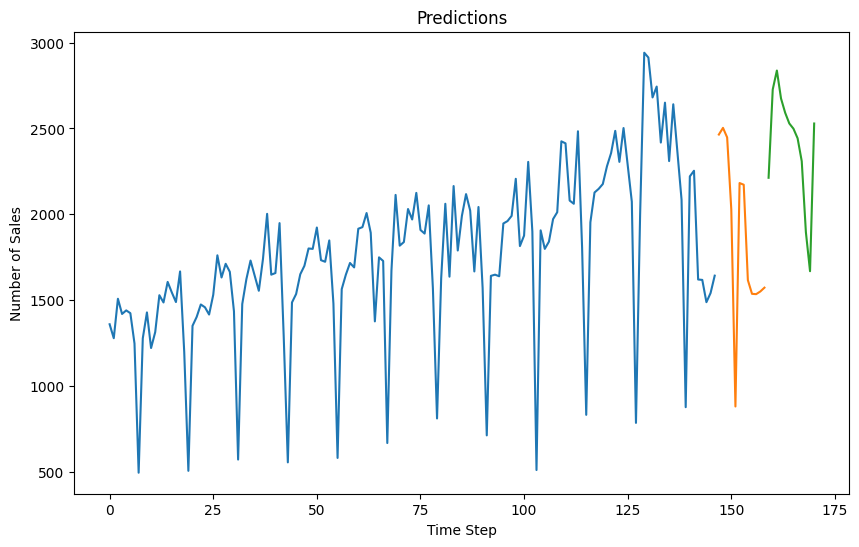

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(Sales_value)

input = normalize_data(np.array(Sales_value[-41:]).reshape(1,-1,1))
y_prediction = denormalize_data(model.predict(input)).flatten()
x_prediction = [len(Sales_value) + i for i in range(12)]
plt.plot(x_prediction,y_prediction)

input = normalize_data(np.array([*Sales_value[-21:], *y_prediction]).reshape(1,-1,1))
y_prediction = denormalize_data(model.predict(input)).flatten()
x_prediction = [len(Sales_value) + i for i in range(12,24)]
plt.plot(x_prediction,y_prediction)

plt.xlabel('Time Step')
plt.ylabel('Number of Sales')
plt.title('Predictions')
plt.show()
